# EDA of the elliptic dataset

In [1]:
import warnings
from pathlib import Path

import pandas as pd
from sklearn.exceptions import UndefinedMetricWarning
from tqdm import tqdm

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [2]:
data_path = Path("../data/01_raw/elliptic_btc/BTC/")
labels = pd.read_csv(data_path / "elliptic_txs_classes.csv")
# labels["class"] = labels["class"].map({"unknown": 0, "1": 1, "2": 2})
edges = pd.read_csv(data_path / "elliptic_txs_edgelist.csv")
features = pd.read_csv(data_path / "elliptic_txs_features.csv", header=None)
features.columns = ["txId", *[f"F{i}" for i in features.columns[1:]]]

In [3]:
labels

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown
...,...,...
203764,173077460,unknown
203765,158577750,unknown
203766,158375402,1
203767,158654197,unknown


In [4]:
print(
    f"""Shapes
\tFeatures : {features.shape[0]:8,} (rows)  {features.shape[1]:4,} (cols)
\tClasses  : {labels.shape[0]:8,} (rows)  {labels.shape[1]:4,} (cols)
\tEdgelist : {edges.shape[0]:8,} (rows)  {edges.shape[1]:4,} (cols)
"""
)

Shapes
	Features :  203,769 (rows)   167 (cols)
	Classes  :  203,769 (rows)     2 (cols)
	Edgelist :  234,355 (rows)     2 (cols)



In [5]:
labels.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [6]:
labels["class"].value_counts()

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

In [7]:
edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [8]:
features.head()

,txId,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F157,F158,F159,F160,F161,F162,F163,F164,F165,F166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [30]:
features.T.describe()

,0,1,2,3,4,5,6,7,8,9,...,203759,203760,203761,203762,203763,203764,203765,203766,203767,203768
count,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,...,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02
mean,1.379796e+06,3.311630e+04,1.389356e+06,1.391847e+06,1.380002e+06,1.379999e+06,1.379245e+06,1.380814e+06,1.389301e+06,1.389397e+06,...,9.483540e+05,9.495778e+05,3.336091e+05,9.436013e+05,8.831036e+05,1.036392e+06,9.495679e+05,9.483561e+05,9.500255e+05,9.436964e+05
std,1.783090e+07,4.279597e+05,1.795444e+07,1.798662e+07,1.783355e+07,1.783352e+07,1.782377e+07,1.784405e+07,1.795373e+07,1.795496e+07,...,1.225543e+07,1.227125e+07,4.311175e+06,1.219401e+07,1.141221e+07,1.339314e+07,1.227111e+07,1.225546e+07,1.227703e+07,1.219524e+07
min,-1.494057e+00,-1.494024e+00,-2.429065e+00,-2.772015e+00,-1.943850e+00,-1.592267e+00,-1.943850e+00,-2.841929e+00,-1.499972e+00,-1.618971e+00,...,-3.745387e+00,-1.373657e+00,-9.689029e-01,-2.429065e+00,-1.059868e+00,-1.059868e+00,-1.760984e+00,-2.283917e+00,-1.084907e+00,-1.084907e+00
25%,-2.354240e-01,-2.413022e-01,-2.633189e-01,-2.009737e-01,-2.974190e-01,-2.640740e-01,-1.794484e-01,-2.757424e-01,-2.619934e-01,-1.961607e-01,...,-1.749193e-01,-2.219547e-01,-1.716759e-01,-1.633810e-01,-9.780664e-02,-1.758589e-01,-1.424875e-01,-1.694966e-01,-1.766199e-01,-1.261526e-01
50%,-1.397312e-01,-1.403346e-01,-1.489107e-01,-6.372457e-02,-8.112744e-02,-1.129692e-01,-9.540269e-02,-1.388688e-01,-1.336630e-01,-7.974637e-02,...,-8.202676e-02,-1.155343e-01,-8.014674e-02,-4.817068e-02,-1.210745e-02,-9.771860e-02,-2.605969e-02,-6.158379e-02,-9.888874e-02,-1.884871e-02
75%,-1.824442e-02,-2.693718e-02,-2.938331e-02,3.511446e-01,2.899864e-01,3.702234e-02,-8.735883e-04,-4.275992e-03,-2.693718e-02,2.998591e-01,...,8.858072e-01,-1.134420e-02,3.702234e-02,1.628747e-01,9.050343e-01,1.455229e-03,7.532952e-01,8.580398e-01,-4.275992e-03,3.546624e-01
max,2.304260e+08,5.530458e+06,2.320225e+08,2.324384e+08,2.304603e+08,2.304599e+08,2.303339e+08,2.305959e+08,2.320133e+08,2.320292e+08,...,1.583751e+08,1.585795e+08,5.571266e+07,1.575813e+08,1.474782e+08,1.730775e+08,1.585778e+08,1.583754e+08,1.586542e+08,1.575972e+08


# Preprocessing the features

In [10]:
from functools import partial, reduce
from typing import Callable

import numpy as np
import torch
import torch.nn.functional as F
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv


def apply_functions(df: pd.DataFrame, functions: list[Callable]) -> pd.DataFrame:
    """applies a list of functions to a dataframe"""
    return reduce(lambda df, func: func(df), functions, df)

In [11]:
transaction_mapper = {tx_id: idx for idx, tx_id in enumerate(features["txId"].unique())}

def filter_edges(edges: pd.DataFrame, transaction_mapper: dict) -> pd.DataFrame:
    """removes all edges that do not have features in the features dataframe"""

    edge_ids = set(transaction_mapper.keys())
    left_condition = edges.txId1.isin(edge_ids)
    right_condition = edges.txId2.isin(edge_ids)
    return edges[left_condition & right_condition]


def add_edge_ids(edges: pd.DataFrame, transaction_mapper: dict) -> pd.DataFrame:
    """adds edge ids to the edges dataframe"""
    edges["left_id"] = edges.txId1.map(transaction_mapper)
    edges["right_id"] = edges.txId2.map(transaction_mapper)

    return edges


def convert_to_tensor(edges: pd.DataFrame) -> torch.Tensor:
    """converts the edges dataframe to a tensor"""
    return torch.tensor(edges[["left_id", "right_id"]].values.T, dtype=torch.long)


edge_index = apply_functions(
    df=edges,
    functions=[
        partial(filter_edges, transaction_mapper=transaction_mapper),
        partial(add_edge_ids, transaction_mapper=transaction_mapper),
        convert_to_tensor,
    ]
)

edge_index

tensor([[     0,      2,      4,  ..., 201921, 201480, 201954],
        [     1,      3,      5,  ..., 202042, 201368, 201756]])

In [12]:
def get_feature_tensor(features: pd.DataFrame) -> torch.Tensor:
    """converts the features dataframe to a tensor"""
    features = features.drop(columns=["txId"])
    return torch.tensor(features.values, dtype=torch.float)


feature_tensor = get_feature_tensor(features)
print(feature_tensor.shape)
feature_tensor

torch.Size([203769, 166])


tensor([[ 1.0000e+00, -1.7147e-01, -1.8467e-01,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 1.0000e+00, -1.7148e-01, -1.8467e-01,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 1.0000e+00, -1.7211e-01, -1.8467e-01,  ..., -1.8367e-01,
         -1.2061e-01, -1.1979e-01],
        ...,
        [ 4.9000e+01, -1.7201e-01, -7.8182e-02,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 4.9000e+01, -1.7284e-01, -1.7662e-01,  ..., -1.4060e-01,
          1.5197e+00,  1.5214e+00],
        [ 4.9000e+01, -1.2037e-02, -1.3228e-01,  ..., -1.4060e-01,
          1.5197e+00,  1.5214e+00]])

In [13]:
le = LabelEncoder()
class_labels = le.fit_transform(labels["class"])
node_labels = torch.tensor(class_labels, dtype=torch.long)
original_labels = le.inverse_transform(class_labels)

print(original_labels)
print(class_labels)
print(node_labels)

print(le.inverse_transform([0]))  # illicit
print(le.inverse_transform([1]))  # licit
print(le.inverse_transform([2]))  # unknown

['unknown' 'unknown' 'unknown' ... '1' 'unknown' 'unknown']
[2 2 2 ... 0 2 2]
tensor([2, 2, 2,  ..., 0, 2, 2])
['1']
['2']
['unknown']


In [14]:
def get_label_tensor(labels: pd.DataFrame) -> torch.Tensor:
    """converts the labels dataframe to a tensor"""
    label_encoder = LabelEncoder()
    class_labels = label_encoder.fit_transform(labels["class"])
    return torch.tensor(class_labels, dtype=torch.long)

node_labels = get_label_tensor(labels)
print(node_labels.shape)
node_labels

torch.Size([203769])


tensor([2, 2, 2,  ..., 0, 2, 2])

In [15]:
node_labels.unique()

tensor([0, 1, 2])

In [16]:
def combine_data(edge_index: torch.Tensor, feature_tensor: torch.Tensor, node_labels: torch.Tensor) -> Data:
    """combines the edge_index, feature_tensor, and node_labels into a single Data object"""
    return Data(edge_index=edge_index, x=feature_tensor, y=node_labels)

data = combine_data(edge_index, feature_tensor, node_labels)

In [17]:
data.y

tensor([2, 2, 2,  ..., 0, 2, 2])

In [18]:
known_mask = (data.y == 0) | (data.y == 1)
unknown_mask = data.y == 2

In [19]:
number_known_nodes = known_mask.sum().item()
permutation = torch.randperm(number_known_nodes)
train_size = int(0.8 * number_known_nodes)
val_size = int(0.1 * number_known_nodes)
test_size = number_known_nodes - train_size - val_size

total = np.sum([train_size, val_size, test_size])
print(
    f"""Number of observations per split
    Training   : {train_size:10,} ({100*train_size/total:0.2f} %)
    Validation : {val_size:10,} ({100*val_size/total:0.2f} %)
    Testing    : {test_size:10,} ({100*test_size/total:0.2f} %)
"""
)

Number of observations per split
    Training   :     37,251 (80.00 %)
    Validation :      4,656 (10.00 %)
    Testing    :      4,657 (10.00 %)



In [20]:
def set_training_masks(data: Data, train_size: int, val_size: int, permutation: torch.Tensor) -> Data:
    """
    sets the training, validation, and testing masks

    Args:
        data (Data): the dataset
        train_size (int): the number of training nodes
        val_size (int): the number of validation nodes
        permutation (torch.Tensor): the permutation of nodes

    Returns:
        Data: the updated dataset with the training, validation, and testing masks set
    """

    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_indices = known_mask.nonzero(as_tuple=True)[0][permutation[:train_size]]
    train_mask[train_indices] = True
    val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    val_indices = known_mask.nonzero(as_tuple=True)[0][permutation[train_size:train_size + val_size]]
    val_mask[val_indices] = True
    test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    test_indices = known_mask.nonzero(as_tuple=True)[0][permutation[train_size + val_size:]]
    test_mask[test_indices] = True

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask

    return data

data = set_training_masks(data, train_size, val_size, permutation)

Let's check some statistincs about train, test and validation sets

In [21]:
data.y[known_mask].unique()

tensor([0, 1])

In [22]:
data.y[data.val_mask].unique()

tensor([0, 1])

In [23]:

train_licit, train_illicit = (data.y[data.train_mask] == 1).sum().item(), (data.y[data.train_mask] == 0).sum().item()
val_licit, val_illicit = (data.y[data.val_mask] == 1).sum().item(), (data.y[data.val_mask] == 0).sum().item()
test_licit, test_illicit = (data.y[data.test_mask] == 1).sum().item(), (data.y[data.test_mask] == 0).sum().item()

# Calculate total counts.
train_total = train_licit + train_illicit
val_total = val_licit + val_illicit
test_total = test_licit + test_illicit

# Calculate percentages.
train_licit_pct = (train_licit / train_total) * 100
train_illicit_pct = (train_illicit / train_total) * 100
val_licit_pct = (val_licit / val_total) * 100
val_illicit_pct = (val_illicit / val_total) * 100
test_licit_pct = (test_licit / test_total) * 100
test_illicit_pct = (test_illicit / test_total) * 100

pd.DataFrame({
    'Set': ['Training', 'Validation', 'Testing'],
    'Total Count': [train_total, val_total, test_total],
    'Licit': [train_licit, val_licit, test_licit],
    'Licit (%)': [train_licit_pct, val_licit_pct, test_licit_pct],
    'Illicit': [train_illicit, val_illicit, test_illicit],
    'Illicit (%)': [train_illicit_pct, val_illicit_pct, test_illicit_pct]
})


,Set,Total Count,Licit,Licit (%),Illicit,Illicit (%)
0,Training,37251,33624,90.263349,3627,9.736651
1,Validation,4656,4199,90.184708,457,9.815292
2,Testing,4657,4196,90.100923,461,9.899077


In [24]:
class GCNModel(torch.nn.Module):
    """Graph Convolutional Network model with batch normalization"""

    def __init__(self, hidden_dim, num_features, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        self.intermediate_conv = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.intermediate_conv(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [25]:
DEVICE_MAPPING = {
    "gpu": torch.cuda,
    "mps": torch.backends.mps,
}

HIDDEN_DIM = 32
def get_torch_device() -> torch.device:
    """gets the best performant device (CPU or MPS)"""
    for device_name, device in DEVICE_MAPPING.items():
        if device.is_available():
            return torch.device(device_name)

    return torch.device("cpu")


device = get_torch_device()
data = data.to(device)
model = GCNModel(hidden_dim=HIDDEN_DIM, num_features=data.x.shape[1], num_classes=2).to(
    device
)

In [29]:
processed_data = catalog.load("processed_data")

NameError: name 'catalog' is not defined

In [28]:
model(data)[data.train_mask]

tensor([[-1.7891e+00, -1.8286e-01],
        [-5.3603e-01, -8.7964e-01],
        [-1.6488e+01, -1.1921e-07],
        ...,
        [-9.2147e-01, -5.0739e-01],
        [-5.0903e-01, -9.1899e-01],
        [-4.0652e+00, -1.7308e-02]], device='mps:0', grad_fn=<IndexBackward0>)

In [184]:
def train_gnn(num_epochs: int, model: torch.nn.Module, data: Data, optimizer: torch.optim.Optimizer) -> dict:
    """trains the GNN model"""
    train_losses = []
    train_accuracies = []
    train_precisions = []
    train_recals = []
    train_f1_scores = []

    val_losses = []
    val_accuracies = []
    val_precisions = []
    val_recals = []
    val_f1_scores = []

    for epoch in tqdm(range(1, num_epochs + 1)):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        train_loss = loss.item()

        train_predictions = out[data.train_mask].argmax(dim=1).cpu().detach().numpy()
        train_true = data.y[data.train_mask].cpu().detach().numpy()

        train_accuracy = metrics.accuracy_score(train_true, train_predictions)
        train_precision = metrics.precision_score(
            train_true, train_predictions, average="weighted"
        ).item()
        train_recall = metrics.recall_score(
            train_true, train_predictions, average="weighted"
        ).item()
        train_f1_score = metrics.f1_score(
            train_true, train_predictions, average="weighted"
        ).item()

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_precisions.append(train_precision)
        train_recals.append(train_recall)
        train_f1_scores.append(train_f1_score)

        model.eval()
        with torch.no_grad():
            out = model(data)
            validation_predictions = out[data.val_mask].argmax(dim=1).cpu().detach().numpy()
            validation_true = data.y[data.val_mask].cpu().detach().numpy()

            val_loss = F.nll_loss(out[data.val_mask], data.y[data.val_mask]).item()
            val_accuracy = metrics.accuracy_score(
                validation_predictions, validation_true
            )
            val_precision = metrics.precision_score(
                validation_predictions, validation_true, average="weighted"
            )
            val_recall = metrics.recall_score(
                validation_predictions, validation_true, average="weighted"
            )
            val_f1_score = metrics.f1_score(
                validation_predictions, validation_true, average="weighted"
            )

            val_losses.append(val_loss)
            val_accuracies.append(val_accuracy)
            val_precisions.append(val_precision)
            val_recals.append(val_recall)
            val_f1_scores.append(val_f1_score)

        if epoch % 10 == 0:
            print(
                f"Epoch: {epoch},\n\tTrain Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Train Precision: {train_precision:.4f}, Train Recall: {train_recall:.4f}, Train F1 Score: {train_f1_score:.4f}\n\tVal Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}, Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}, Val F1 Score: {val_f1_score:.4f}"
            )

    return {
        "model": model,
        "train": {
            "losses": train_losses,
            "accuracies": train_accuracies,
            "precisions": train_precisions,
            "recals": train_recals,
            "f1_scores": train_f1_scores
        },
        "val": {
            "losses": val_losses,
            "accuracies": val_accuracies,
            "precisions": val_precisions,
            "recals": val_recals,
            "f1_scores": val_f1_scores,
        }
    }

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc, confusion_matrix, roc_curve


def plot_confusion_matrix_and_roc(y_true, y_pred, y_pred_proba):
    """
    Generate and plot confusion matrix and ROC curve.

    Args:
    y_true (array-like): True labels
    y_pred (array-like): Predicted labels
    y_pred_proba (array-like): Predicted probabilities for the positive class

    Returns:
    None (displays the plots)
    """
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.subplot(1, 2, 2)
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

In [186]:
results = train_gnn(num_epochs=250, model=model, data=data, optimizer=torch.optim.Adam(model.parameters(), lr=0.01))

  4%|▍         | 11/250 [00:02<00:32,  7.31it/s]

Epoch: 10,
	Train Loss: 0.2926, Train Accuracy: 0.8837, Train Precision: 0.8501, Train Recall: 0.8837, Train F1 Score: 0.8629
	Val Loss: 0.2471, Val Accuracy: 0.9059, Val Precision: 0.9716, Val Recall: 0.9059, Val F1 Score: 0.9342


  8%|▊         | 21/250 [00:03<00:30,  7.63it/s]

Epoch: 20,
	Train Loss: 0.2531, Train Accuracy: 0.9003, Train Precision: 0.8599, Train Recall: 0.9003, Train F1 Score: 0.8610
	Val Loss: 0.2237, Val Accuracy: 0.9046, Val Precision: 0.9968, Val Recall: 0.9046, Val F1 Score: 0.9473


 12%|█▏        | 31/250 [00:04<00:27,  7.94it/s]

...

Epoch: 230,
	Train Loss: 0.1515, Train Accuracy: 0.9457, Train Precision: 0.9423, Train Recall: 0.9457, Train F1 Score: 0.9431
	Val Loss: 0.1299, Val Accuracy: 0.9577, Val Precision: 0.9620, Val Recall: 0.9577, Val F1 Score: 0.9593


 96%|█████████▋| 241/250 [00:31<00:01,  7.82it/s]

Epoch: 240,
	Train Loss: 0.1495, Train Accuracy: 0.9466, Train Precision: 0.9431, Train Recall: 0.9466, Train F1 Score: 0.9439
	Val Loss: 0.1295, Val Accuracy: 0.9581, Val Precision: 0.9646, Val Recall: 0.9581, Val F1 Score: 0.9604


100%|██████████| 250/250 [00:32<00:00,  7.59it/s]

Epoch: 250,
	Train Loss: 0.1506, Train Accuracy: 0.9454, Train Precision: 0.9417, Train Recall: 0.9454, Train F1 Score: 0.9423
	Val Loss: 0.1281, Val Accuracy: 0.9585, Val Precision: 0.9650, Val Recall: 0.9585, Val F1 Score: 0.9608


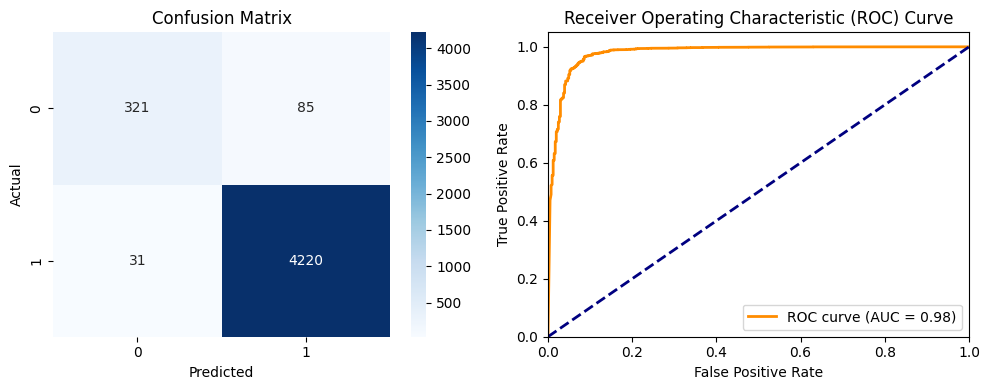

In [165]:
model = results["model"]
model.eval()
with torch.no_grad():
    out = model(data)
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
    y_pred_proba = F.softmax(out[data.test_mask], dim=1)[:, 1].cpu().numpy()

# Now plot the confusion matrix and ROC curve
plot_confusion_matrix_and_roc(y_true, y_pred, y_pred_proba)

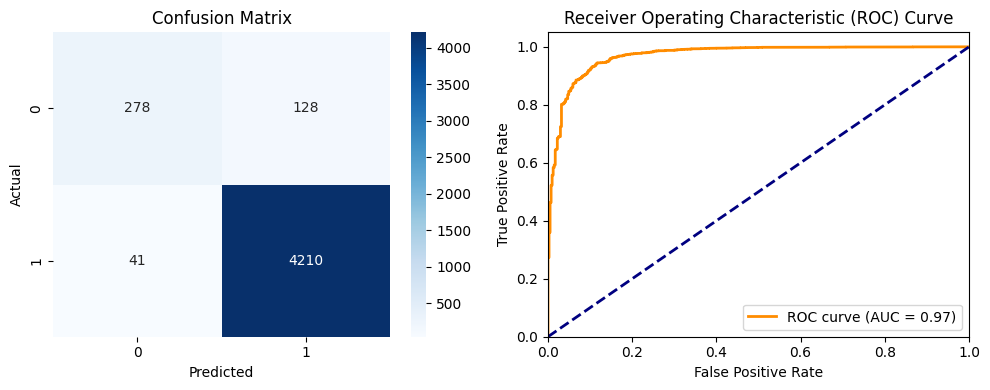

In [168]:
model = results["model"]
model.eval()
with torch.no_grad():
    out = model(data)
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
    y_pred_proba = F.softmax(out[data.test_mask], dim=1)[:, 1].cpu().numpy()

# Now plot the confusion matrix and ROC curve
plot_confusion_matrix_and_roc(y_true, y_pred, y_pred_proba)

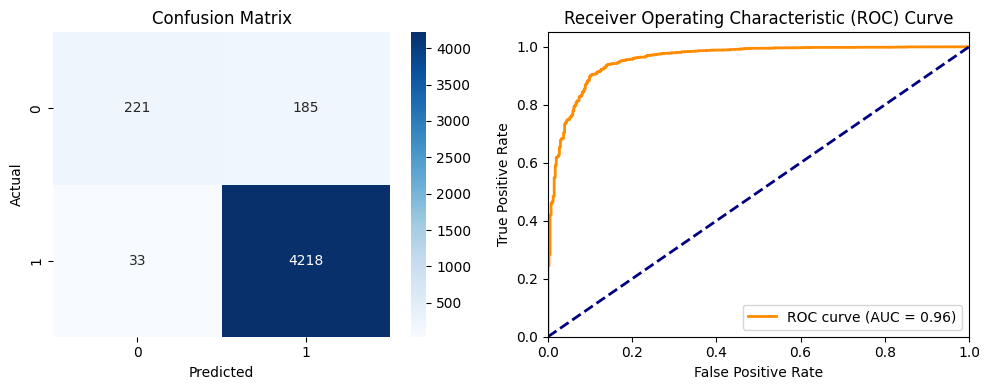

In [173]:
model = results["model"]
model.eval()
with torch.no_grad():
    out = model(data)
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
    y_pred_proba = F.softmax(out[data.test_mask], dim=1)[:, 1].cpu().numpy()

# Now plot the confusion matrix and ROC curve
plot_confusion_matrix_and_roc(y_true, y_pred, y_pred_proba)

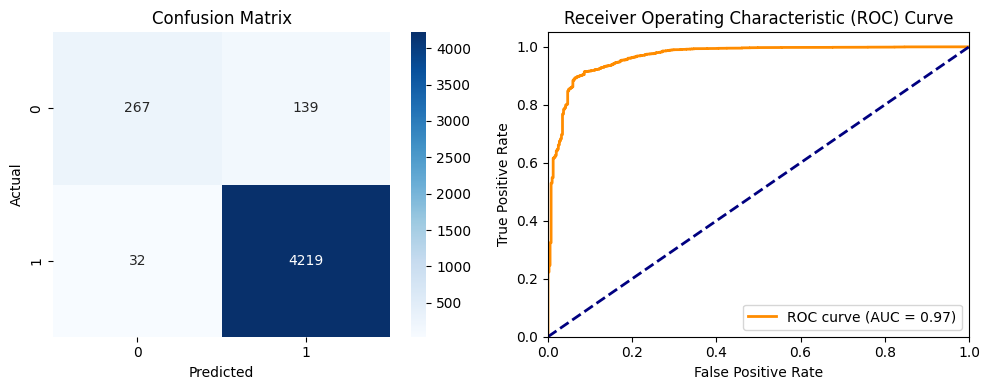

In [179]:
model = results["model"]
model.eval()
with torch.no_grad():
    out = model(data)
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
    y_pred_proba = F.softmax(out[data.test_mask], dim=1)[:, 1].cpu().numpy()

# Now plot the confusion matrix and ROC curve
plot_confusion_matrix_and_roc(y_true, y_pred, y_pred_proba)

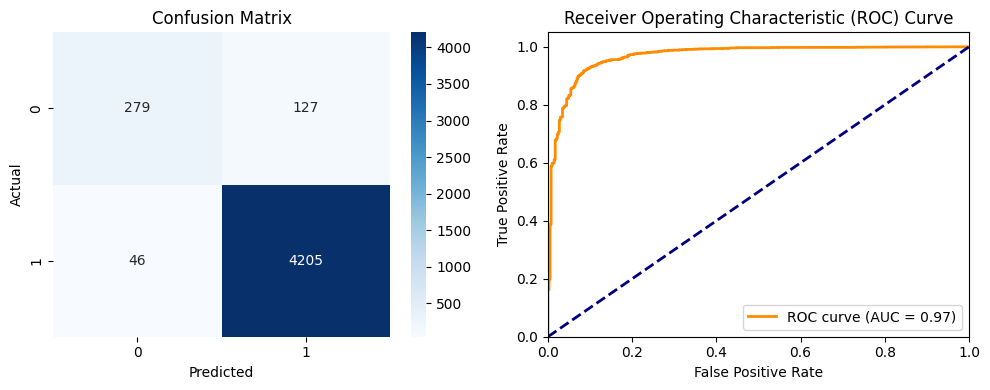

In [187]:
model = results["model"]
model.eval()
with torch.no_grad():
    out = model(data)
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
    y_pred_proba = F.softmax(out[data.test_mask], dim=1)[:, 1].cpu().numpy()

# Now plot the confusion matrix and ROC curve
plot_confusion_matrix_and_roc(y_true, y_pred, y_pred_proba)

In [127]:
data.y[data.test_mask].unique()

tensor([1, 2], device='mps:0')